# SVM

#### Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

from src.svm_experiment import SVMExperiment
from src.utils import evaluate_model, save_results

c:\Users\renan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experimento 1: Conjunto com todas as Features

In [2]:
import pandas as pd
caminho = '../'

X_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### SVM - Default

In [3]:
from sklearn.svm import SVC

svm_exp1 = SVC(kernel='rbf', probability=True, random_state=14)
svm_exp1.fit(X_train_exp1, y_train_exp1)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


=== Métricas svm_def_exp1  ===
    Acurácia: 0.8108
    Precisão: 0.7996
    Recall:   0.7517
    F1-Score: 0.7673
    MCC:      0.5492
    AUC:      0.8611


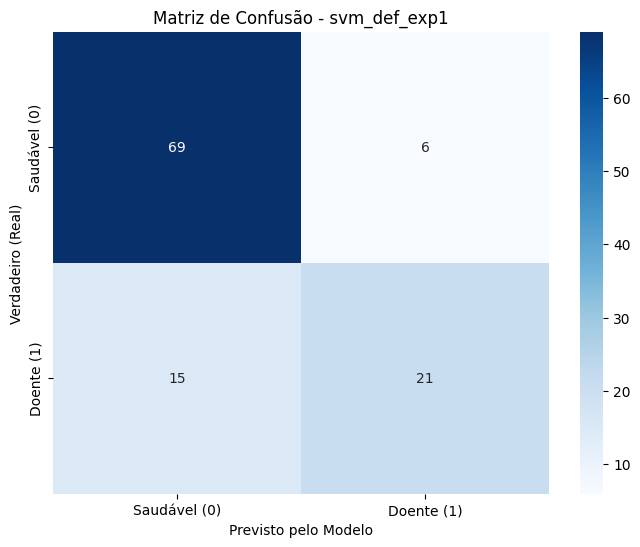

In [4]:
# Avaliar modelo
y_pred_def_exp1 = svm_exp1.predict(X_test_exp1)
y_prob_def_exp1 = svm_exp1.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_def_exp1, y_prob_def_exp1, 'svm_def_exp1')
save_results(y_pred_def_exp1, y_prob_def_exp1, 'svm_def_exp1', caminho)

### SVM - Melhorado

In [5]:
# Criar o experimento
experimento_1 = SVMExperiment(X_train_exp1, y_train_exp1, 'svm_otz_exp1', caminho)
experimento_1.tune_and_fit(n_trials=50)
best_svm = experimento_1.best_model

[I 2026-08-18 19:06:26,651] A new study created in memory with name: no-name-604f3fc1-3cad-4c09-9283-fa2e8d0d22d9


Iniciando otimização do cenário svm_otz_exp1.


Best trial: 0. Best value: 0.670543:   2%|▏         | 1/50 [00:08<06:55,  8.49s/it]

[I 2026-08-18 19:06:35,125] Trial 0 finished with value: 0.6705426356589147 and parameters: {'kernel': 'sigmoid', 'C': 0.18044539987187821, 'gamma': 'auto', 'tol': 0.03474016473126724, 'shrinking': True, 'coef0': 0.09641907230347757}. Best is trial 0 with value: 0.6705426356589147.


Best trial: 0. Best value: 0.670543:   4%|▍         | 2/50 [00:13<05:10,  6.46s/it]

[I 2026-08-18 19:06:40,178] Trial 1 finished with value: 0.6705426356589147 and parameters: {'kernel': 'poly', 'C': 0.7492066705501214, 'gamma': 'auto', 'tol': 6.472863234679661e-05, 'shrinking': False, 'degree': 3, 'coef0': 0.18794830922156036}. Best is trial 0 with value: 0.6705426356589147.


Best trial: 0. Best value: 0.670543:   6%|▌         | 3/50 [00:18<04:37,  5.91s/it]

[I 2026-08-18 19:06:45,421] Trial 2 finished with value: 0.5813953488372093 and parameters: {'kernel': 'sigmoid', 'C': 72.9963042467552, 'gamma': 'scale', 'tol': 8.953494553948938e-05, 'shrinking': True, 'coef0': 0.09286954580906637}. Best is trial 0 with value: 0.6705426356589147.


Best trial: 4. Best value: 0.825581:  12%|█▏        | 6/50 [00:24<01:58,  2.70s/it]

[I 2026-08-18 19:06:50,754] Trial 3 finished with value: 0.6705426356589147 and parameters: {'kernel': 'poly', 'C': 0.26806220805071335, 'gamma': 'auto', 'tol': 0.0028081091734637703, 'shrinking': True, 'degree': 2, 'coef0': 0.6318088420370891}. Best is trial 0 with value: 0.6705426356589147.
[I 2026-08-18 19:06:50,815] Trial 4 finished with value: 0.8255813953488372 and parameters: {'kernel': 'poly', 'C': 4.820056668157933, 'gamma': 'auto', 'tol': 0.0788226850008963, 'shrinking': True, 'degree': 4, 'coef0': 0.9796139258689122}. Best is trial 4 with value: 0.8255813953488372.
[I 2026-08-18 19:06:50,887] Trial 5 finished with value: 0.7364341085271318 and parameters: {'kernel': 'poly', 'C': 8.473131314566572, 'gamma': 'scale', 'tol': 0.007187420852498682, 'shrinking': True, 'degree': 4, 'coef0': 0.10221327431840321}. Best is trial 4 with value: 0.8255813953488372.


Best trial: 4. Best value: 0.825581:  20%|██        | 10/50 [00:24<00:39,  1.00it/s]

[I 2026-08-18 19:06:50,984] Trial 6 finished with value: 0.7364341085271318 and parameters: {'kernel': 'poly', 'C': 5.901674148915838, 'gamma': 'scale', 'tol': 8.876031861684959e-05, 'shrinking': True, 'degree': 4, 'coef0': 0.718353087433416}. Best is trial 4 with value: 0.8255813953488372.
[I 2026-08-18 19:06:51,047] Trial 7 finished with value: 0.7945736434108527 and parameters: {'kernel': 'rbf', 'C': 20.445854398461158, 'gamma': 'scale', 'tol': 0.006323587424255241, 'shrinking': True}. Best is trial 4 with value: 0.8255813953488372.
[I 2026-08-18 19:06:51,100] Trial 8 finished with value: 0.6705426356589147 and parameters: {'kernel': 'sigmoid', 'C': 1.1207670932587563, 'gamma': 'auto', 'tol': 3.7357592051655424e-05, 'shrinking': False, 'coef0': 0.5574632287622799}. Best is trial 4 with value: 0.8255813953488372.
[I 2026-08-18 19:06:51,157] Trial 9 finished with value: 0.8217054263565892 and parameters: {'kernel': 'poly', 'C': 3.2302822964745093, 'gamma': 'auto', 'tol': 0.00016575103

Best trial: 11. Best value: 0.829457:  28%|██▊       | 14/50 [00:24<00:16,  2.14it/s]

[I 2026-08-18 19:06:51,258] Trial 10 finished with value: 0.8255813953488372 and parameters: {'kernel': 'rbf', 'C': 32.468164737454195, 'gamma': 'auto', 'tol': 0.08582680117957853, 'shrinking': False}. Best is trial 4 with value: 0.8255813953488372.
[I 2026-08-18 19:06:51,323] Trial 11 finished with value: 0.8294573643410853 and parameters: {'kernel': 'rbf', 'C': 44.76279285116153, 'gamma': 'auto', 'tol': 0.07820108774786216, 'shrinking': False}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:51,371] Trial 12 finished with value: 0.8255813953488372 and parameters: {'kernel': 'rbf', 'C': 16.938811262515326, 'gamma': 'auto', 'tol': 0.0218588350327321, 'shrinking': False}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:51,434] Trial 13 finished with value: 0.8217054263565892 and parameters: {'kernel': 'rbf', 'C': 91.82092477059008, 'gamma': 'auto', 'tol': 0.0005864192620550243, 'shrinking': False}. Best is trial 11 with value: 0.8294573643410853

Best trial: 11. Best value: 0.829457:  36%|███▌      | 18/50 [00:25<00:07,  4.10it/s]

[I 2026-08-18 19:06:51,490] Trial 14 finished with value: 0.6976744186046511 and parameters: {'kernel': 'rbf', 'C': 1.67209168997821, 'gamma': 'auto', 'tol': 0.09175065170111, 'shrinking': False}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:51,539] Trial 15 finished with value: 0.8294573643410853 and parameters: {'kernel': 'poly', 'C': 6.141385955475744, 'gamma': 'auto', 'tol': 0.01569548435328656, 'shrinking': False, 'degree': 3, 'coef0': 0.9241555578812333}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:51,594] Trial 16 finished with value: 0.8294573643410853 and parameters: {'kernel': 'rbf', 'C': 39.52929135190058, 'gamma': 'auto', 'tol': 1.0394185913465916e-05, 'shrinking': False}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:51,644] Trial 17 finished with value: 0.8062015503875969 and parameters: {'kernel': 'poly', 'C': 10.34870891982478, 'gamma': 'auto', 'tol': 0.017957068652777134, 'shrinking': False, 'degre

Best trial: 11. Best value: 0.829457:  44%|████▍     | 22/50 [00:25<00:04,  6.14it/s]

[I 2026-08-18 19:06:51,707] Trial 18 finished with value: 0.7713178294573643 and parameters: {'kernel': 'rbf', 'C': 43.9127643511966, 'gamma': 'scale', 'tol': 0.001168526946614112, 'shrinking': False}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:51,747] Trial 19 finished with value: 0.6705426356589147 and parameters: {'kernel': 'sigmoid', 'C': 0.5612595795425097, 'gamma': 'auto', 'tol': 0.005202398235434671, 'shrinking': False, 'coef0': 0.8023043775350902}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:51,781] Trial 20 finished with value: 0.7015503875968991 and parameters: {'kernel': 'rbf', 'C': 1.796881212453591, 'gamma': 'auto', 'tol': 0.030158915612014354, 'shrinking': False}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:51,823] Trial 21 finished with value: 0.8294573643410853 and parameters: {'kernel': 'rbf', 'C': 33.72516670750272, 'gamma': 'auto', 'tol': 1.618123663567155e-05, 'shrinking': False}. Best is tr

Best trial: 11. Best value: 0.829457:  54%|█████▍    | 27/50 [00:25<00:02, 10.90it/s]

[I 2026-08-18 19:06:51,901] Trial 23 finished with value: 0.8178294573643411 and parameters: {'kernel': 'rbf', 'C': 53.217301144038736, 'gamma': 'auto', 'tol': 0.0006865581650034661, 'shrinking': False}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:51,943] Trial 24 finished with value: 0.8255813953488372 and parameters: {'kernel': 'rbf', 'C': 25.75233519371992, 'gamma': 'auto', 'tol': 0.0002949514111348463, 'shrinking': False}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:51,983] Trial 25 finished with value: 0.8062015503875969 and parameters: {'kernel': 'poly', 'C': 11.384984295612096, 'gamma': 'auto', 'tol': 0.011147186625610407, 'shrinking': False, 'degree': 3, 'coef0': 0.4237115331992942}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:52,027] Trial 26 finished with value: 0.7635658914728681 and parameters: {'kernel': 'rbf', 'C': 55.56069470793695, 'gamma': 'scale', 'tol': 0.0025056225385591234, 'shrinking': Fals

Best trial: 11. Best value: 0.829457:  68%|██████▊   | 34/50 [00:25<00:00, 17.10it/s]

[I 2026-08-18 19:06:52,092] Trial 28 finished with value: 0.8294573643410853 and parameters: {'kernel': 'sigmoid', 'C': 95.2077425539576, 'gamma': 'auto', 'tol': 0.0023714608954146267, 'shrinking': False, 'coef0': 0.8268058637848898}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:52,125] Trial 29 finished with value: 0.6705426356589147 and parameters: {'kernel': 'poly', 'C': 0.17088200332123346, 'gamma': 'auto', 'tol': 0.04518802586626216, 'shrinking': False, 'degree': 3, 'coef0': 0.3299030543660124}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:52,158] Trial 30 finished with value: 0.6705426356589147 and parameters: {'kernel': 'sigmoid', 'C': 3.396171211281341, 'gamma': 'auto', 'tol': 0.013727637232082455, 'shrinking': False, 'coef0': 0.8582365207343043}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:52,190] Trial 31 finished with value: 0.8255813953488372 and parameters: {'kernel': 'rbf', 'C': 31.90559668585499, 'g

Best trial: 11. Best value: 0.829457:  76%|███████▌  | 38/50 [00:25<00:00, 18.57it/s]

[I 2026-08-18 19:06:52,296] Trial 34 finished with value: 0.8294573643410853 and parameters: {'kernel': 'rbf', 'C': 13.841452465647917, 'gamma': 'auto', 'tol': 4.2734740665492345e-05, 'shrinking': False}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:52,340] Trial 35 finished with value: 0.8178294573643411 and parameters: {'kernel': 'poly', 'C': 66.66708952939545, 'gamma': 'auto', 'tol': 0.00022374646282275322, 'shrinking': False, 'degree': 3, 'coef0': 0.6506616625152933}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:52,389] Trial 36 finished with value: 0.810077519379845 and parameters: {'kernel': 'rbf', 'C': 7.909682060780326, 'gamma': 'scale', 'tol': 1.2614084185548579e-05, 'shrinking': False}. Best is trial 11 with value: 0.8294573643410853.
[I 2026-08-18 19:06:52,428] Trial 37 finished with value: 0.6705426356589147 and parameters: {'kernel': 'poly', 'C': 0.32356791954665926, 'gamma': 'auto', 'tol': 6.424167436346474e-05, 'shrinking':

Best trial: 43. Best value: 0.837209:  86%|████████▌ | 43/50 [00:26<00:00, 20.91it/s]

[I 2026-08-18 19:06:52,516] Trial 39 finished with value: 0.8333333333333334 and parameters: {'kernel': 'poly', 'C': 20.894190227309252, 'gamma': 'auto', 'tol': 2.0139777092282183e-05, 'shrinking': False, 'degree': 3, 'coef0': 0.7330265161109782}. Best is trial 39 with value: 0.8333333333333334.
[I 2026-08-18 19:06:52,553] Trial 40 finished with value: 0.8217054263565892 and parameters: {'kernel': 'poly', 'C': 7.84946789154947, 'gamma': 'auto', 'tol': 0.00013222957981094753, 'shrinking': True, 'degree': 3, 'coef0': 0.7344993714871169}. Best is trial 39 with value: 0.8333333333333334.
[I 2026-08-18 19:06:52,591] Trial 41 finished with value: 0.8294573643410853 and parameters: {'kernel': 'poly', 'C': 23.653588323197855, 'gamma': 'auto', 'tol': 2.3646405086971532e-05, 'shrinking': False, 'degree': 3, 'coef0': 0.7492121286036741}. Best is trial 39 with value: 0.8333333333333334.
[I 2026-08-18 19:06:52,640] Trial 42 finished with value: 0.8294573643410853 and parameters: {'kernel': 'poly', 

Best trial: 43. Best value: 0.837209:  92%|█████████▏| 46/50 [00:26<00:00, 22.32it/s]

[I 2026-08-18 19:06:52,721] Trial 44 finished with value: 0.8372093023255814 and parameters: {'kernel': 'poly', 'C': 18.163623871384658, 'gamma': 'auto', 'tol': 3.037896374841198e-05, 'shrinking': False, 'degree': 3, 'coef0': 0.9175796711947392}. Best is trial 43 with value: 0.8372093023255814.
[I 2026-08-18 19:06:52,755] Trial 45 finished with value: 0.8372093023255814 and parameters: {'kernel': 'poly', 'C': 17.095036876453943, 'gamma': 'auto', 'tol': 4.1363941818090724e-05, 'shrinking': False, 'degree': 3, 'coef0': 0.9120591691060136}. Best is trial 43 with value: 0.8372093023255814.
[I 2026-08-18 19:06:52,894] Trial 46 finished with value: 0.7248062015503876 and parameters: {'kernel': 'poly', 'C': 16.368070762553998, 'gamma': 'scale', 'tol': 4.388305726737468e-05, 'shrinking': False, 'degree': 3, 'coef0': 0.9813496749546815}. Best is trial 43 with value: 0.8372093023255814.


Best trial: 43. Best value: 0.837209: 100%|██████████| 50/50 [00:26<00:00,  1.90it/s]

[I 2026-08-18 19:06:52,929] Trial 47 finished with value: 0.8294573643410853 and parameters: {'kernel': 'poly', 'C': 12.069742035638457, 'gamma': 'auto', 'tol': 0.00010272817285060764, 'shrinking': True, 'degree': 3, 'coef0': 0.8741843673623471}. Best is trial 43 with value: 0.8372093023255814.
[I 2026-08-18 19:06:52,963] Trial 48 finished with value: 0.8333333333333334 and parameters: {'kernel': 'poly', 'C': 20.524908237788054, 'gamma': 'auto', 'tol': 3.104557553779053e-05, 'shrinking': False, 'degree': 3, 'coef0': 0.7882722967846416}. Best is trial 43 with value: 0.8372093023255814.
[I 2026-08-18 19:06:52,999] Trial 49 finished with value: 0.6705426356589147 and parameters: {'kernel': 'poly', 'C': 0.1083853418768483, 'gamma': 'auto', 'tol': 2.9496775398820584e-05, 'shrinking': False, 'degree': 3, 'coef0': 0.7886721921638985}. Best is trial 43 with value: 0.8372093023255814.
Melhor pontuação (CV): 0.8372
Melhores parâmetros:
{'kernel': 'poly', 'C': 18.025075609256053, 'gamma': 'auto',

In [6]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_1.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_1.study)
fig.show()

=== Métricas svm_otz_exp1  ===
    Acurácia: 0.8288
    Precisão: 0.8121
    Recall:   0.7867
    F1-Score: 0.7969
    MCC:      0.5982
    AUC:      0.8389


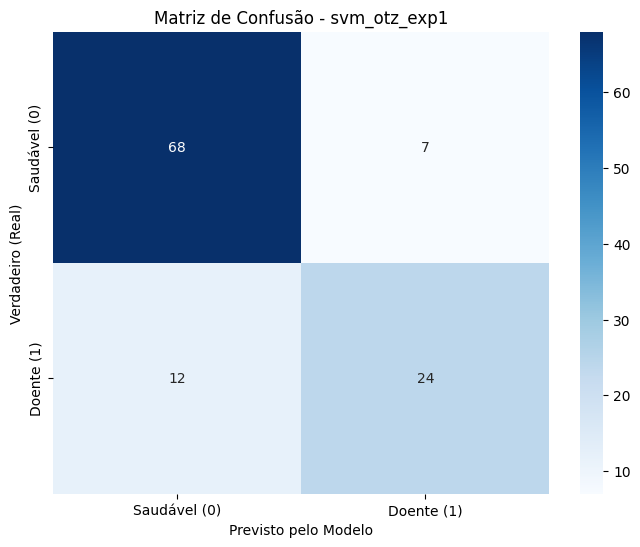

In [7]:
# Avaliar resultados e salvar
y_pred_otz_exp1 = experimento_1.best_model.predict(X_test_exp1)
y_prob_otz_exp1 = experimento_1.best_model.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_otz_exp1, y_prob_otz_exp1, 'svm_otz_exp1')
save_results(y_pred_otz_exp1, y_prob_otz_exp1, 'svm_otz_exp1', caminho)

## Experimento 2: Conjunto com PCA

In [8]:
X_test_exp2 = pd.read_csv(caminho + 'database/processed/splitted/X_test_pca.csv')
X_train_exp2 = pd.read_csv(caminho + 'database/processed/splitted/X_train_pca.csv')
y_test_exp2 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp2 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### SVM - Default

In [9]:
from sklearn.svm import SVC

svm_exp2 = SVC(kernel='rbf', probability=True, random_state=14)
svm_exp2.fit(X_train_exp2, y_train_exp2)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


=== Métricas svm_def_exp2  ===
    Acurácia: 0.8018
    Precisão: 0.7846
    Recall:   0.7450
    F1-Score: 0.7585
    MCC:      0.5282
    AUC:      0.8681


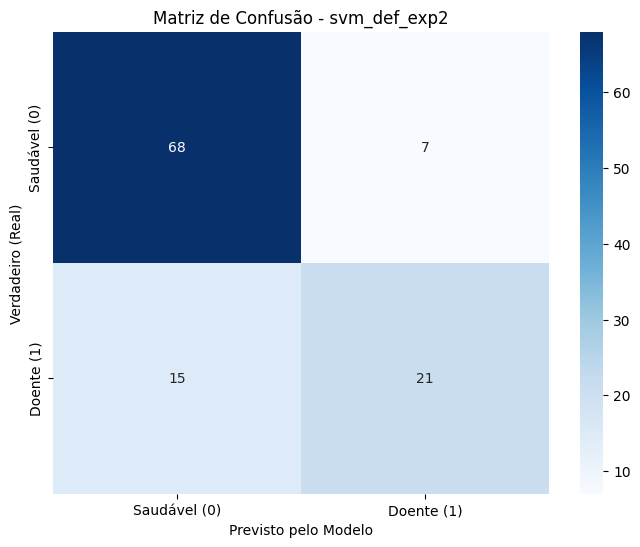

In [10]:
# Avaliar modelo
y_pred_def_exp2 = svm_exp2.predict(X_test_exp2)
y_prob_def_exp2 = svm_exp2.predict_proba(X_test_exp2)[:, 1]

evaluate_model(y_test_exp2, y_pred_def_exp2, y_prob_def_exp2, 'svm_def_exp2')
save_results(y_pred_def_exp2, y_prob_def_exp2, 'svm_def_exp2', caminho)

### SVM - Melhorado

In [11]:
# Criar o experimento
experimento_2 = SVMExperiment(X_train_exp2, y_train_exp2, 'svm_otz_exp2', caminho)
experimento_2.tune_and_fit(n_trials=50)

[I 2026-08-18 19:06:55,099] A new study created in memory with name: no-name-293f98a3-a305-42ad-8187-5443c2a6b24c


Iniciando otimização do cenário svm_otz_exp2.


Best trial: 1. Best value: 0.810078:   4%|▍         | 2/50 [00:00<00:02, 19.41it/s]

[I 2026-08-18 19:06:55,148] Trial 0 finished with value: 0.6705426356589147 and parameters: {'kernel': 'sigmoid', 'C': 0.26951346777268814, 'gamma': 'auto', 'tol': 0.024624281940101623, 'shrinking': True, 'coef0': 0.444988450376007}. Best is trial 0 with value: 0.6705426356589147.
[I 2026-08-18 19:06:55,199] Trial 1 finished with value: 0.810077519379845 and parameters: {'kernel': 'rbf', 'C': 1.8929780482425627, 'gamma': 'scale', 'tol': 0.02905195565985472, 'shrinking': False}. Best is trial 1 with value: 0.810077519379845.
[I 2026-08-18 19:06:55,247] Trial 2 finished with value: 0.806201550387597 and parameters: {'kernel': 'rbf', 'C': 0.7979204688771326, 'gamma': 'scale', 'tol': 0.010621856826376133, 'shrinking': True}. Best is trial 1 with value: 0.810077519379845.


Best trial: 1. Best value: 0.810078:   8%|▊         | 4/50 [00:00<00:02, 19.41it/s]

[I 2026-08-18 19:06:55,287] Trial 3 finished with value: 0.6705426356589147 and parameters: {'kernel': 'rbf', 'C': 0.3425193800320435, 'gamma': 'auto', 'tol': 0.007825240125444648, 'shrinking': True}. Best is trial 1 with value: 0.810077519379845.
[I 2026-08-18 19:06:55,341] Trial 4 finished with value: 0.7403100775193798 and parameters: {'kernel': 'poly', 'C': 6.926247451542114, 'gamma': 'scale', 'tol': 0.00020606565241357522, 'shrinking': True, 'degree': 3, 'coef0': 0.6015586759150864}. Best is trial 1 with value: 0.810077519379845.


Best trial: 1. Best value: 0.810078:  10%|█         | 5/50 [00:00<00:02, 20.41it/s]

[I 2026-08-18 19:06:55,424] Trial 5 finished with value: 0.7558139534883721 and parameters: {'kernel': 'poly', 'C': 23.55862675766592, 'gamma': 'scale', 'tol': 0.0008415819662016411, 'shrinking': True, 'degree': 2, 'coef0': 0.7403832404232563}. Best is trial 1 with value: 0.810077519379845.


Best trial: 1. Best value: 0.810078:  16%|█▌        | 8/50 [00:00<00:02, 18.24it/s]

[I 2026-08-18 19:06:55,471] Trial 6 finished with value: 0.7674418604651163 and parameters: {'kernel': 'poly', 'C': 1.3454940166741969, 'gamma': 'scale', 'tol': 0.021856898571698577, 'shrinking': False, 'degree': 4, 'coef0': 0.15523243435323253}. Best is trial 1 with value: 0.810077519379845.
[I 2026-08-18 19:06:55,523] Trial 7 finished with value: 0.8062015503875969 and parameters: {'kernel': 'sigmoid', 'C': 7.517691736192853, 'gamma': 'auto', 'tol': 0.057153824550089986, 'shrinking': False, 'coef0': 0.41324774631806827}. Best is trial 1 with value: 0.810077519379845.
[I 2026-08-18 19:06:55,578] Trial 8 finished with value: 0.6627906976744186 and parameters: {'kernel': 'sigmoid', 'C': 23.31623097235599, 'gamma': 'scale', 'tol': 0.001896343228630449, 'shrinking': False, 'coef0': 0.7394831782427199}. Best is trial 1 with value: 0.810077519379845.


Best trial: 1. Best value: 0.810078:  18%|█▊        | 9/50 [00:00<00:02, 18.24it/s]

[I 2026-08-18 19:06:55,631] Trial 9 finished with value: 0.7984496124031009 and parameters: {'kernel': 'poly', 'C': 0.10657074341504354, 'gamma': 'scale', 'tol': 0.016058574306807037, 'shrinking': True, 'degree': 2, 'coef0': 0.7725097441488313}. Best is trial 1 with value: 0.810077519379845.


Best trial: 10. Best value: 0.817829:  22%|██▏       | 11/50 [00:00<00:02, 17.51it/s]

[I 2026-08-18 19:06:55,701] Trial 10 finished with value: 0.8178294573643411 and parameters: {'kernel': 'rbf', 'C': 59.12256536130201, 'gamma': 'auto', 'tol': 1.3652032345836393e-05, 'shrinking': False}. Best is trial 10 with value: 0.8178294573643411.
[I 2026-08-18 19:06:55,779] Trial 11 finished with value: 0.810077519379845 and parameters: {'kernel': 'rbf', 'C': 94.85116510329114, 'gamma': 'auto', 'tol': 2.03049324158638e-05, 'shrinking': False}. Best is trial 10 with value: 0.8178294573643411.


Best trial: 10. Best value: 0.817829:  26%|██▌       | 13/50 [00:00<00:02, 17.65it/s]

[I 2026-08-18 19:06:55,826] Trial 12 finished with value: 0.8023255813953488 and parameters: {'kernel': 'rbf', 'C': 2.4906368725945254, 'gamma': 'auto', 'tol': 1.0191424904884143e-05, 'shrinking': False}. Best is trial 10 with value: 0.8178294573643411.


Best trial: 10. Best value: 0.817829:  30%|███       | 15/50 [00:00<00:02, 16.15it/s]

[I 2026-08-18 19:06:55,898] Trial 13 finished with value: 0.8178294573643411 and parameters: {'kernel': 'rbf', 'C': 53.40053116546441, 'gamma': 'auto', 'tol': 0.0001384331162061295, 'shrinking': False}. Best is trial 10 with value: 0.8178294573643411.
[I 2026-08-18 19:06:55,975] Trial 14 finished with value: 0.810077519379845 and parameters: {'kernel': 'rbf', 'C': 95.89716127446529, 'gamma': 'auto', 'tol': 5.6527632821195e-05, 'shrinking': False}. Best is trial 10 with value: 0.8178294573643411.


Best trial: 15. Best value: 0.821705:  30%|███       | 15/50 [00:00<00:02, 16.15it/s]

[I 2026-08-18 19:06:56,028] Trial 15 finished with value: 0.8217054263565892 and parameters: {'kernel': 'rbf', 'C': 34.13511238612726, 'gamma': 'auto', 'tol': 9.486397420662485e-05, 'shrinking': False}. Best is trial 15 with value: 0.8217054263565892.


Best trial: 15. Best value: 0.821705:  34%|███▍      | 17/50 [00:01<00:02, 16.18it/s]

[I 2026-08-18 19:06:56,095] Trial 16 finished with value: 0.8178294573643411 and parameters: {'kernel': 'rbf', 'C': 21.81638563754033, 'gamma': 'auto', 'tol': 5.0903599404917875e-05, 'shrinking': False}. Best is trial 15 with value: 0.8217054263565892.
[I 2026-08-18 19:06:56,159] Trial 17 finished with value: 0.8178294573643411 and parameters: {'kernel': 'rbf', 'C': 11.594287527501134, 'gamma': 'auto', 'tol': 0.00040730256870140006, 'shrinking': False}. Best is trial 15 with value: 0.8217054263565892.


Best trial: 15. Best value: 0.821705:  38%|███▊      | 19/50 [00:01<00:02, 15.45it/s]

[I 2026-08-18 19:06:56,224] Trial 18 finished with value: 0.8178294573643411 and parameters: {'kernel': 'rbf', 'C': 51.466033793560406, 'gamma': 'auto', 'tol': 4.1310841911577376e-05, 'shrinking': False}. Best is trial 15 with value: 0.8217054263565892.


[I 2026-08-18 19:06:56,321] Trial 19 finished with value: 0.8217054263565892 and parameters: {'kernel': 'sigmoid', 'C': 40.4597339514159, 'gamma': 'auto', 'tol': 1.0283572046753917e-05, 'shrinking': False, 'coef0': 0.0065527644995020395}. Best is trial 15 with value: 0.8217054263565892.


[I 2026-08-18 19:06:56,416] Trial 20 finished with value: 0.7984496124031008 and parameters: {'kernel': 'sigmoid', 'C': 5.605071189497785, 'gamma': 'auto', 'tol': 0.00010094639898477171, 'shrinking': False, 'coef0': 0.05197904333346194}. Best is trial 15 with value: 0.8217054263565892.


Best trial: 15. Best value: 0.821705:  44%|████▍     | 22/50 [00:01<00:02, 13.33it/s]

[I 2026-08-18 19:06:56,513] Trial 21 finished with value: 0.8217054263565892 and parameters: {'kernel': 'sigmoid', 'C': 43.72494426606196, 'gamma': 'auto', 'tol': 1.2310500101315027e-05, 'shrinking': False, 'coef0': 0.9950711656039684}. Best is trial 15 with value: 0.8217054263565892.
[I 2026-08-18 19:06:56,600] Trial 22 finished with value: 0.8062015503875969 and parameters: {'kernel': 'sigmoid', 'C': 16.042283005188562, 'gamma': 'auto', 'tol': 2.5689238723595702e-05, 'shrinking': False, 'coef0': 0.9823263648824291}. Best is trial 15 with value: 0.8217054263565892.


Best trial: 23. Best value: 0.829457:  50%|█████     | 25/50 [00:01<00:02, 12.22it/s]

[I 2026-08-18 19:06:56,708] Trial 23 finished with value: 0.8294573643410853 and parameters: {'kernel': 'sigmoid', 'C': 36.70453459123043, 'gamma': 'auto', 'tol': 2.6938430470377116e-05, 'shrinking': False, 'coef0': 0.2710097579969909}. Best is trial 23 with value: 0.8294573643410853.
[I 2026-08-18 19:06:56,796] Trial 24 finished with value: 0.8255813953488372 and parameters: {'kernel': 'sigmoid', 'C': 27.193248675090544, 'gamma': 'auto', 'tol': 0.0003603522519946455, 'shrinking': False, 'coef0': 0.22404623575083604}. Best is trial 23 with value: 0.8294573643410853.
[I 2026-08-18 19:06:56,862] Trial 25 finished with value: 0.7868217054263567 and parameters: {'kernel': 'sigmoid', 'C': 4.524668320244626, 'gamma': 'auto', 'tol': 0.0003505771842939799, 'shrinking': False, 'coef0': 0.24123955357551882}. Best is trial 23 with value: 0.8294573643410853.


Best trial: 23. Best value: 0.829457:  54%|█████▍    | 27/50 [00:01<00:01, 12.78it/s]

[I 2026-08-18 19:06:56,924] Trial 26 finished with value: 0.8062015503875969 and parameters: {'kernel': 'sigmoid', 'C': 11.714486392568018, 'gamma': 'auto', 'tol': 0.0024546955073120025, 'shrinking': False, 'coef0': 0.2905423448507597}. Best is trial 23 with value: 0.8294573643410853.
[I 2026-08-18 19:06:57,013] Trial 27 finished with value: 0.8294573643410853 and parameters: {'kernel': 'sigmoid', 'C': 29.166785954475582, 'gamma': 'auto', 'tol': 0.00010413114365727983, 'shrinking': False, 'coef0': 0.32775599300890645}. Best is trial 23 with value: 0.8294573643410853.


Best trial: 23. Best value: 0.829457:  62%|██████▏   | 31/50 [00:02<00:01, 13.09it/s]

[I 2026-08-18 19:06:57,105] Trial 28 finished with value: 0.8178294573643411 and parameters: {'kernel': 'sigmoid', 'C': 12.999250285142285, 'gamma': 'auto', 'tol': 0.0006996837222276894, 'shrinking': False, 'coef0': 0.36046164322987934}. Best is trial 23 with value: 0.8294573643410853.
[I 2026-08-18 19:06:57,188] Trial 29 finished with value: 0.8217054263565892 and parameters: {'kernel': 'sigmoid', 'C': 29.86694910623519, 'gamma': 'auto', 'tol': 0.00025684934362949944, 'shrinking': True, 'coef0': 0.1802417788706027}. Best is trial 23 with value: 0.8294573643410853.
[I 2026-08-18 19:06:57,243] Trial 30 finished with value: 0.7364341085271318 and parameters: {'kernel': 'sigmoid', 'C': 3.4837226195847073, 'gamma': 'auto', 'tol': 0.0022337794634564464, 'shrinking': False, 'coef0': 0.5349118935565228}. Best is trial 23 with value: 0.8294573643410853.


Best trial: 23. Best value: 0.829457:  70%|███████   | 35/50 [00:02<00:00, 15.14it/s]

[I 2026-08-18 19:06:57,295] Trial 31 finished with value: 0.8294573643410853 and parameters: {'kernel': 'sigmoid', 'C': 31.10490888119134, 'gamma': 'auto', 'tol': 9.111829909905037e-05, 'shrinking': False, 'coef0': 0.3343693794791383}. Best is trial 23 with value: 0.8294573643410853.
[I 2026-08-18 19:06:57,368] Trial 32 finished with value: 0.813953488372093 and parameters: {'kernel': 'sigmoid', 'C': 73.46605846123875, 'gamma': 'auto', 'tol': 7.98490888716637e-05, 'shrinking': False, 'coef0': 0.30578854258173593}. Best is trial 23 with value: 0.8294573643410853.
[I 2026-08-18 19:06:57,418] Trial 33 finished with value: 0.8217054263565892 and parameters: {'kernel': 'sigmoid', 'C': 15.5980722558044, 'gamma': 'auto', 'tol': 3.0236406903798277e-05, 'shrinking': False, 'coef0': 0.11889248536727606}. Best is trial 23 with value: 0.8294573643410853.
[I 2026-08-18 19:06:57,467] Trial 34 finished with value: 0.810077519379845 and parameters: {'kernel': 'sigmoid', 'C': 8.702989395570478, 'gamma'

Best trial: 37. Best value: 0.837209:  74%|███████▍  | 37/50 [00:02<00:00, 15.42it/s]

[I 2026-08-18 19:06:57,518] Trial 35 finished with value: 0.8294573643410853 and parameters: {'kernel': 'sigmoid', 'C': 20.51046588537598, 'gamma': 'auto', 'tol': 0.00014329724989525593, 'shrinking': True, 'coef0': 0.36887572215207265}. Best is trial 23 with value: 0.8294573643410853.
[I 2026-08-18 19:06:57,590] Trial 36 finished with value: 0.7364341085271318 and parameters: {'kernel': 'sigmoid', 'C': 0.5657177802500052, 'gamma': 'scale', 'tol': 0.00014774762126699197, 'shrinking': True, 'coef0': 0.3721355288004805}. Best is trial 23 with value: 0.8294573643410853.
[I 2026-08-18 19:06:57,656] Trial 37 finished with value: 0.8372093023255814 and parameters: {'kernel': 'sigmoid', 'C': 17.30153198613004, 'gamma': 'auto', 'tol': 6.4742240754631e-05, 'shrinking': True, 'coef0': 0.498970830804154}. Best is trial 37 with value: 0.8372093023255814.


Best trial: 37. Best value: 0.837209:  82%|████████▏ | 41/50 [00:02<00:00, 16.46it/s]

[I 2026-08-18 19:06:57,710] Trial 38 finished with value: 0.751937984496124 and parameters: {'kernel': 'poly', 'C': 33.061828018646196, 'gamma': 'scale', 'tol': 3.547605856987801e-05, 'shrinking': True, 'degree': 4, 'coef0': 0.5158348287610561}. Best is trial 37 with value: 0.8372093023255814.
[I 2026-08-18 19:06:57,759] Trial 39 finished with value: 0.6705426356589147 and parameters: {'kernel': 'sigmoid', 'C': 1.23605653315294, 'gamma': 'auto', 'tol': 6.406661125988733e-05, 'shrinking': True, 'coef0': 0.6234864339306092}. Best is trial 37 with value: 0.8372093023255814.
[I 2026-08-18 19:06:57,825] Trial 40 finished with value: 0.7403100775193798 and parameters: {'kernel': 'poly', 'C': 9.318622583499826, 'gamma': 'scale', 'tol': 2.109018027028268e-05, 'shrinking': True, 'degree': 3, 'coef0': 0.4593150068692873}. Best is trial 37 with value: 0.8372093023255814.
[I 2026-08-18 19:06:57,877] Trial 41 finished with value: 0.8333333333333334 and parameters: {'kernel': 'sigmoid', 'C': 19.6345

Best trial: 37. Best value: 0.837209:  92%|█████████▏| 46/50 [00:02<00:00, 19.02it/s]

[I 2026-08-18 19:06:57,928] Trial 42 finished with value: 0.813953488372093 and parameters: {'kernel': 'sigmoid', 'C': 72.15851413993491, 'gamma': 'auto', 'tol': 0.0006811410658257806, 'shrinking': True, 'coef0': 0.3333348684824945}. Best is trial 37 with value: 0.8372093023255814.
[I 2026-08-18 19:06:57,975] Trial 43 finished with value: 0.8333333333333334 and parameters: {'kernel': 'sigmoid', 'C': 19.394726796659267, 'gamma': 'auto', 'tol': 0.00496767174698728, 'shrinking': True, 'coef0': 0.4587397827506402}. Best is trial 37 with value: 0.8372093023255814.
[I 2026-08-18 19:06:58,012] Trial 44 finished with value: 0.8294573643410853 and parameters: {'kernel': 'sigmoid', 'C': 18.517420965576502, 'gamma': 'auto', 'tol': 0.004718080016793167, 'shrinking': True, 'coef0': 0.43957864128940644}. Best is trial 37 with value: 0.8372093023255814.
[I 2026-08-18 19:06:58,059] Trial 45 finished with value: 0.7829457364341086 and parameters: {'kernel': 'sigmoid', 'C': 5.013063400957532, 'gamma': '

Best trial: 37. Best value: 0.837209: 100%|██████████| 50/50 [00:03<00:00, 15.78it/s]


[I 2026-08-18 19:06:58,152] Trial 47 finished with value: 0.7596899224806202 and parameters: {'kernel': 'poly', 'C': 7.73718559317291, 'gamma': 'scale', 'tol': 0.006120187454691986, 'shrinking': True, 'degree': 4, 'coef0': 0.41526355136132187}. Best is trial 37 with value: 0.8372093023255814.
[I 2026-08-18 19:06:58,222] Trial 48 finished with value: 0.813953488372093 and parameters: {'kernel': 'sigmoid', 'C': 67.15731718728684, 'gamma': 'auto', 'tol': 0.018061499875535892, 'shrinking': True, 'coef0': 0.5652921517197249}. Best is trial 37 with value: 0.8372093023255814.
[I 2026-08-18 19:06:58,268] Trial 49 finished with value: 0.8255813953488372 and parameters: {'kernel': 'sigmoid', 'C': 42.61587483928209, 'gamma': 'auto', 'tol': 0.003893718398346445, 'shrinking': True, 'coef0': 0.47354655884247737}. Best is trial 37 with value: 0.8372093023255814.
Melhor pontuação (CV): 0.8372
Melhores parâmetros:
{'kernel': 'sigmoid', 'C': 17.30153198613004, 'gamma': 'auto', 'tol': 6.4742240754631e-05

In [12]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_2.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_2.study)
fig.show()

=== Métricas svm_otz_exp2  ===
    Acurácia: 0.8108
    Precisão: 0.7939
    Recall:   0.7589
    F1-Score: 0.7716
    MCC:      0.5517
    AUC:      0.8211


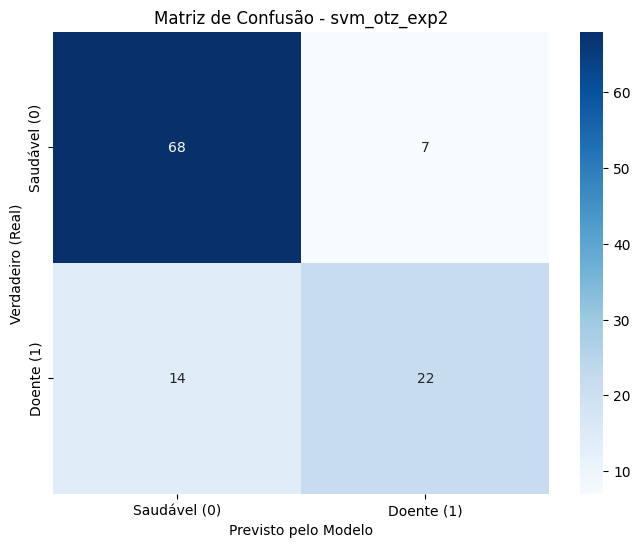

In [13]:
# Avaliar resultados e salvar
y_pred_otz_exp2 = experimento_2.best_model.predict(X_test_exp2)
y_prob_otz_exp2 = experimento_2.best_model.predict_proba(X_test_exp2)[:, 1]

evaluate_model(y_test_exp2, y_pred_otz_exp2, y_prob_otz_exp2, 'svm_otz_exp2')
save_results(y_pred_otz_exp2, y_prob_otz_exp2, 'svm_otz_exp2', caminho)